# Maven Music - Python EDA Project

## 1. Scope the Project

Tha aim is discover what might cause customers to cancel their subscription with Maven Music using the past three months of customer data which includes subscription and listening history. This project covers all the steps up to data preparation for Modelling.

Covered:
* Data Gathering
* Data Cleaning
* Data Exploration
* Data prep for Modelling

What is not covered:
* Modelling
* Predicting the customers likely to cancel

 

## 2. Gather Data

Data Sources: 
* Customer data
* Listing history
* audio library
* session details

  

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

In [7]:
# Read in the customer data

customers = pd.read_csv('../Data/maven_music_customers.csv')
customers.head()


,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [8]:
# Read in the listening history

listening_history = pd.read_excel('../Data/maven_music_listening_history.xlsx', sheet_name = 0)
listening_history.head()


,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [9]:
# Read in the audio data

audio = pd.read_excel('../Data/maven_music_listening_history.xlsx', sheet_name = 1)
audio.head()


,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52


In [10]:
# Read in the session data

session = pd.read_excel('../Data/maven_music_listening_history.xlsx', sheet_name = 2)
session.head()



,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


## 3. Clean Data

### a. Convert Data Types

Check the data types of the data in the tables and convert to numeric and datetime values as necessary.

In [11]:
# Check the data types

In [12]:
# customers

customers.shape

(30, 8)

In [13]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer ID        30 non-null     int64 
 1   Customer Name      30 non-null     object
 2   Email              30 non-null     object
 3   Member Since       30 non-null     object
 4   Subscription Plan  25 non-null     object
 5   Subscription Rate  30 non-null     object
 6   Discount?          7 non-null      object
 7   Cancellation Date  13 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.0+ KB


In [14]:
# Observation: 
# Member Since - date
# Subscription rate - int
# Cancellation date - date


# Convert objects to numeric and datetime fields

In [15]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [16]:
customers['Member Since'] = pd.to_datetime(customers['Member Since'], format = '%m/%d/%y')

In [17]:
customers['Cancellation Date'] = pd.to_datetime(customers['Cancellation Date'], format = '%m/%d/%y')

In [18]:
customers['Subscription Rate'] = pd.to_numeric(customers['Subscription Rate'].str.replace('$', ''))

In [19]:
customers.info()

# all datatypes look clean now.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  25 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          7 non-null      object        
 7   Cancellation Date  13 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 2.0+ KB


In [20]:
# listening_history 

listening_history.info()

# all datatypes look clean

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer ID  505 non-null    int64 
 1   Session ID   505 non-null    int64 
 2   Audio Order  505 non-null    int64 
 3   Audio ID     505 non-null    int64 
 4   Audio Type   505 non-null    object
dtypes: int64(4), object(1)
memory usage: 19.9+ KB


In [21]:
# session

session.info()

# all datatypes look clean

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Session ID           90 non-null     int64         
 1   Session Log In Time  90 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.5 KB


In [22]:
# audio

In [23]:

audio.info()

# ID coln in audio df needs to be split. This can be done in the new column creation section
# all datatypes look clean

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          17 non-null     object
 1   Name        17 non-null     object
 2   Genre       17 non-null     object
 3   Popularity  17 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 676.0+ bytes


### b. Resolve Data Issues

Check for missing data, inconsistent text and typos, duplicate data and outliers.

#### i. Missing Data

In [24]:
# Look for NaN values in the data


In [25]:
customers.isna().sum()

Customer ID           0
Customer Name         0
Email                 0
Member Since          0
Subscription Plan     5
Subscription Rate     0
Discount?            23
Cancellation Date    17
dtype: int64

In [26]:
# NaN discovered

# Subscription Plan - Need to impute data
# Discount? - Valid NaNs
# Cancellation Date - Valid NaNs


In [27]:
customers[customers.isna().any(axis =1)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,NaN,2023-06-03
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,NaN,NaT
7,5759,Carol Kingbird,Email: songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,NaN,2023-06-02
8,5761,Sonata Nash,Email: musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,NaN,NaT
9,5763,Jazz Coleman,Email: coleman.jazzmaster@email.com,2023-03-28,Basic (Ads),2.99,NaN,NaT


In [28]:
# Subscription Plan

customers['Subscription Plan'].value_counts(dropna = False)


Subscription Plan
Premium (No Ads)    13
Basic (Ads)         12
NaN                  5
Name: count, dtype: int64

In [29]:
customers[customers['Subscription Plan'].isna()]


,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,NaN,2023-06-03
11,5827,Rhythm Franklin,Email: rhythmic.franklin@email.edu,2023-03-28,NaN,2.99,NaN,NaT


In [30]:
customers[customers['Subscription Rate'] == 2.99]

# looks like the Subcription Plan for 2.99 is Basic(Ads). Hence we can update the NaNs using this value.

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,NaN,2023-06-03
9,5763,Jazz Coleman,Email: coleman.jazzmaster@email.com,2023-03-28,Basic (Ads),2.99,NaN,NaT
10,5826,Chord Hayes,Email: harmonic.chord@email.com,2023-03-28,Basic (Ads),2.99,NaN,NaT
11,5827,Rhythm Franklin,Email: rhythmic.franklin@email.edu,2023-03-28,NaN,2.99,NaN,NaT
13,6092,Benny Beat,Email: rhythmic.benny@email.com,2023-04-01,Basic (Ads),2.99,NaN,2023-06-01


In [31]:
# update the NaNs in plan to Basic(Ads).

customers['Subscription Plan'] = np.where(customers['Subscription Plan'].isna(), 'Basic (Ads)', customers['Subscription Plan'])

In [32]:
customers[customers['Subscription Plan'].isna()]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


In [33]:
customers['Subscription Plan'].value_counts(dropna = False)

Subscription Plan
Basic (Ads)         17
Premium (No Ads)    13
Name: count, dtype: int64

In [34]:
customers.isna().sum()

Customer ID           0
Customer Name         0
Email                 0
Member Since          0
Subscription Plan     0
Subscription Rate     0
Discount?            23
Cancellation Date    17
dtype: int64

In [35]:
# Discount coln is changed to integer for ease in manipulation

customers['Discount?'] = np.where(customers['Discount?'] == 'Yes', 1, 0)

In [36]:
customers.tail()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
25,7224,Melody Fitzgerald,Email: fitzgerald.melody@email.com,2023-05-08,Premium (No Ads),7.99,1,2023-06-01
26,7401,Reed Murphy,Email: murphy.reed.music@email.com,2023-05-08,Premium (No Ads),7.99,1,2023-06-01
27,7579,Jazz Drummond,Email: drumming.jazz@email.com,2023-05-15,Basic (Ads),2.99,0,NaT
28,7581,Lyric Keys,Email: keysoflyric@email.com,2023-05-16,Premium (No Ads),7.99,1,2023-06-03
29,7583,Melody Singer,Email: melodic.singer@email.com,2023-05-16,Premium (No Ads),7.99,1,2023-06-01


In [37]:
# listening_history

In [38]:
listening_history.isna().sum()

Customer ID    0
Session ID     0
Audio Order    0
Audio ID       0
Audio Type     0
dtype: int64

In [39]:
session.isna().sum()

Session ID             0
Session Log In Time    0
dtype: int64

In [40]:
audio.isna().sum()

ID            0
Name          0
Genre         0
Popularity    0
dtype: int64

#### ii. Inconsistent Text & Typos

In [41]:
# Look for inconsistent text & typos


In [42]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  30 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          30 non-null     int32         
 7   Cancellation Date  13 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int32(1), int64(1), object(3)
memory usage: 1.9+ KB


In [43]:
customers['Subscription Rate'].value_counts()

Subscription Rate
2.99     17
7.99      7
9.99      5
99.99     1
Name: count, dtype: int64

In [44]:
customers['Discount?'].value_counts()

Discount?
0    23
1     7
Name: count, dtype: int64

In [45]:
customers['Email']

0       Email: harmonious.vibes@email.com
1         Email: melodious.aria@email.edu
2       Email: rhythmical.lyric@email.com
3            Email: groovy.rock@email.com
4        Email: beats.by.rhythm@email.edu
5              Email: jazzy.sax@email.com
6            Email: sharp.tunes@email.com
7         Email: songbird.carol@email.com
8         Email: musical.sonata@email.com
9     Email: coleman.jazzmaster@email.com
10        Email: harmonic.chord@email.com
11     Email: rhythmic.franklin@email.edu
12     Email: campbell.chordify@email.com
13        Email: rhythmic.benny@email.com
14      Email: park.of.melodies@email.com
15       Email: rhodes.symphony@email.com
16     Email: beats.by.beatrice@email.com
17     Email: bass.master.bobby@email.edu
18      Email: lyrical.saunders@email.edu
19          Email: bass.harmony@email.com
20            Email: flat.tunes@email.edu
21       Email: kiki.keys.piano@email.com
22          Email: groovy.greta@email.com
23     Email: heartfelt.harmony@em

In [46]:
customers['Member Since'].dt.day.sort_values()

23     1
22     1
21     1
13     1
14     5
15     6
24     7
26     8
25     8
16     8
17     9
0     13
1     13
2     13
27    15
29    16
28    16
18    16
19    16
3     20
5     20
4     20
6     21
7     22
20    24
8     28
9     28
10    28
11    28
12    29
Name: Member Since, dtype: int32

In [47]:
# listening_history

In [48]:
listening_history

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song
...,...,...,...,...,...
500,7579,111282,4,111,Song
501,6588,111286,1,201,Podcast
502,5763,111333,1,110,Song
503,5763,111333,2,108,Song


In [49]:
listening_history['Audio Type'].value_counts().sort_values()

Audio Type
Podcast     42
Song       463
Name: count, dtype: int64

In [50]:
# listening_history

In [51]:
# session

In [52]:
session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Session ID           90 non-null     int64         
 1   Session Log In Time  90 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.5 KB


In [53]:
session['Session ID'].value_counts().sort_values()

Session ID
100520    1
100538    1
100542    1
100549    1
100556    1
         ..
111282    1
111286    1
109672    1
109661    1
111333    1
Name: count, Length: 90, dtype: int64

In [54]:
session['Session Log In Time'].value_counts().sort_values()

Session Log In Time
2023-03-13 18:29:00    1
2023-03-21 12:23:00    1
2023-03-21 19:29:00    1
2023-03-22 00:30:00    1
2023-03-22 07:02:00    1
                      ..
2023-05-23 23:51:00    1
2023-05-27 02:15:00    1
2023-04-05 19:35:00    1
2023-03-28 21:26:00    1
2023-05-27 20:46:00    1
Name: count, Length: 90, dtype: int64

In [55]:
session['Session Log In Time'].dt.day.value_counts().sort_index()

Session Log In Time
1     5
2     1
3     2
5     4
6     3
7     1
8     4
9     3
10    1
11    2
12    4
13    4
14    1
16    5
17    2
18    3
19    4
20    4
21    7
22    5
23    4
24    1
25    1
26    1
27    3
28    2
29    7
30    4
31    2
Name: count, dtype: int64

In [56]:
# audio

In [57]:
audio.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52


In [58]:
audio.Genre.value_counts()

Genre
Pop Music     3
Hip Hop       3
Comedy        3
Pop           2
Country       2
Jazz          2
True Crime    2
Name: count, dtype: int64

In [59]:
audio['Genre'] = np.where(audio.Genre == 'Pop Music', 'Pop', audio.Genre)

In [60]:
audio['ID'].value_counts()

ID
Song-101       1
Song-110       1
Podcast-204    1
Podcast-203    1
Podcast-202    1
Podcast-201    1
Song-112       1
Song-111       1
Song-109       1
Song-102       1
Song-108       1
Song-107       1
Song-106       1
Song-105       1
Song-104       1
Song-103       1
Podcast-205    1
Name: count, dtype: int64

In [61]:
audio['Popularity'].value_counts().sort_index()

Popularity
1     1
2     2
4     2
5     1
8     1
9     1
10    1
17    1
20    1
23    1
28    1
30    1
52    1
63    1
80    1
Name: count, dtype: int64

#### iii. Duplicate Rows

In [62]:
# Look for duplicate rows


In [63]:
customers[customers.duplicated()]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


In [64]:
listening_history[listening_history.duplicated()]

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type


In [65]:
audio[audio.duplicated()]

,ID,Name,Genre,Popularity


In [66]:
session[session.duplicated()]

,Session ID,Session Log In Time


In [67]:
listening_history.duplicated().sum()

0

#### iv. Outliers

In [68]:
# Look for outliers


In [69]:
# there is one row where rate is 99.99. this looks like a typo. 

customers[customers['Subscription Rate'] == 99.99]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
15,6229,Symphony Rhodes,Email: rhodes.symphony@email.com,2023-04-06,Premium (No Ads),99.99,0,2023-06-02


In [70]:
# correct the 99.99 to 9.99.

customers['Subscription Rate'] = np.where(customers['Subscription Rate'] == 99.99, 9.99, customers['Subscription Rate'])

In [71]:
customers[customers['Subscription Rate'] == 99.99]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


In [72]:
customers['Subscription Rate'].value_counts()

Subscription Rate
2.99    17
7.99     7
9.99     6
Name: count, dtype: int64

In [73]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT


In [74]:
customers.describe()

,Customer ID,Member Since,Subscription Rate,Discount?,Cancellation Date
count,30.000000,30,30.000000,30.000000,13
mean,6276.333333,2023-04-10 06:24:00,5.556667,0.233333,2023-06-01 16:36:55.384615424
min,5001.000000,2023-03-13 00:00:00,2.990000,0.000000,2023-06-01 00:00:00
25%,5759.500000,2023-03-23 12:00:00,2.990000,0.000000,2023-06-01 00:00:00
50%,6196.000000,2023-04-05 12:00:00,2.990000,0.000000,2023-06-02 00:00:00
75%,6823.500000,2023-05-01 00:00:00,7.990000,0.000000,2023-06-02 00:00:00
max,7583.000000,2023-05-16 00:00:00,9.990000,1.000000,2023-06-03 00:00:00
std,814.255587,NaN,3.058998,0.430183,NaN


In [75]:
customers['Member Since'].value_counts(dropna = False)

Member Since
2023-03-28    4
2023-03-13    3
2023-03-20    3
2023-05-01    3
2023-05-08    2
2023-04-16    2
2023-05-16    2
2023-04-05    1
2023-04-06    1
2023-04-01    1
2023-04-09    1
2023-03-29    1
2023-04-24    1
2023-03-22    1
2023-05-07    1
2023-03-21    1
2023-05-15    1
2023-04-08    1
Name: count, dtype: int64

### c. Create New Columns

Create two new columns that will be useful for EDA and modeling:
* Cancelled: whether a customer cancelled or not
* Email: Remove the "Email:" from the email addresses

In [76]:
# Create a 'Cancelled' column

customers.head()


,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT


In [77]:
customers['Cancelled'] = np.where(customers['Cancellation Date'].notna(), 1, 0)

In [78]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


In [79]:
# Create an updated 'Email' column without the Email: portion

customers['Email'] = customers['Email'].str.replace('Email: ', '')

# Alternate #
# customers.Email.str[6:]

In [80]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


In [81]:
# Separate [ID] into [Audio ID] & [Audio Type]

audio.tail()

,ID,Name,Genre,Popularity
12,Podcast-201,Jokes on Jokes,Comedy,2
13,Podcast-202,Laugh Out Loudcast,Comedy,8
14,Podcast-203,The Comedian's Corner,Comedy,20
15,Podcast-204,Crime Chronicles,True Crime,4
16,Podcast-205,Investigating Darkness,True Crime,17


In [82]:
audio[['Audio Type', 'Audio ID']] = audio['ID'].str.split('-').to_list()

In [83]:
audio['Audio ID'] = pd.to_numeric(audio['Audio ID'])

In [84]:
listening_history.tail()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
500,7579,111282,4,111,Song
501,6588,111286,1,201,Podcast
502,5763,111333,1,110,Song
503,5763,111333,2,108,Song
504,5763,111333,3,110,Song


In [85]:
listening_history['Audio ID'].value_counts()

Audio ID
103    71
101    52
105    50
102    48
104    46
110    38
106    37
107    31
109    28
111    28
108    22
112    20
204     9
202     9
205     6
201     6
203     4
Name: count, dtype: int64

In [86]:
listening_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer ID  505 non-null    int64 
 1   Session ID   505 non-null    int64 
 2   Audio Order  505 non-null    int64 
 3   Audio ID     505 non-null    int64 
 4   Audio Type   505 non-null    object
dtypes: int64(4), object(1)
memory usage: 19.9+ KB


In [87]:
audio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          17 non-null     object
 1   Name        17 non-null     object
 2   Genre       17 non-null     object
 3   Popularity  17 non-null     int64 
 4   Audio Type  17 non-null     object
 5   Audio ID    17 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 948.0+ bytes


## 4. EDA

Try to better understand the customers who cancelled:
* How long were they members before they cancelled?
* What percentage of customers who cancelled had a discount vs customers who didn't cancel?

In [88]:
# How long were customers members before they cancelled?


In [89]:
customers['Max Member'] = customers['Member Since'].max()

In [90]:
(customers['Max Member']-customers['Member Since']).dt.days

0     64
1     64
2     64
3     57
4     57
5     57
6     56
7     55
8     49
9     49
10    49
11    49
12    48
13    45
14    41
15    40
16    38
17    37
18    30
19    30
20    22
21    15
22    15
23    15
24     9
25     8
26     8
27     1
28     0
29     0
dtype: int64

In [91]:
customers['Membership Duration'] = np.where(customers['Cancelled'] == 1, (customers['Cancellation Date'] - customers['Member Since']).dt.days, 
                          (customers['Max Member']-customers['Member Since']).dt.days)


In [92]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Max Member,Membership Duration
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0,2023-05-16,64.0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0,2023-05-16,64.0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1,2023-05-16,80.0
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0,2023-05-16,57.0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0,2023-05-16,57.0


In [93]:
# How long where they members before they cancelled?

customers[customers['Cancelled'] == 1]['Membership Duration'].mean()




46.30769230769231

➜ Customers who cancelled where members for approximately 46.30 days 

In [95]:
# Cancellation rate for those who had a discount

discount = customers[customers['Discount?'] == 1]
non_dis = customers[customers['Discount?'] == 0]

In [98]:
# Cancellation rate for those who had a discount
discount['Cancelled'].sum() / discount['Cancelled'].count()

0.8571428571428571

➜ About 85% of people with discounts cancelled their membership

In [99]:
# Cancellation rate for those who did not have a discount
non_dis['Cancelled'].sum() / non_dis['Cancelled'].count()

0.30434782608695654

➜ Only 30% people without discounts cancelled their membership

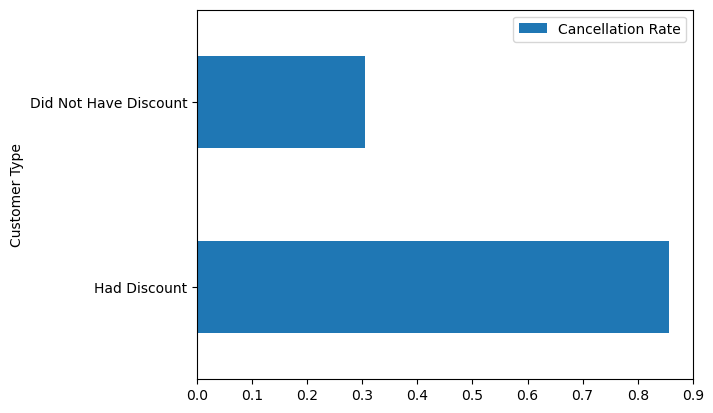

In [153]:
# Visualize the cancellation rate for those with a discount vs those without a discount

(pd.DataFrame([['Had Discount', 0.8571428571428571],['Did Not Have Discount', 0.30434782608695654]], 
              columns = ['Customer Type', 'Cancellation Rate'])
             .plot.barh(x = 'Customer Type', y = 'Cancellation Rate'));


Better understand the customers' listening histories:
* Join together the listening history and audio tables
* How many listening sessions did each customer have in the past 3 months?
* What were the most popular genres that customers listened to?

In [105]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [106]:
customer_sessions_count = listening_history.groupby('Customer ID')['Session ID'].nunique().rename('No of sessions').to_frame().reset_index()

In [107]:
customer_sessions_count

,Customer ID,No of sessions
0,5001,8
1,5002,4
2,5004,1
3,5267,7
4,5338,4
5,5404,1
6,5581,3
7,5759,2
8,5761,3
9,5763,6


In [108]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Max Member,Membership Duration
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0,2023-05-16,64.0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0,2023-05-16,64.0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1,2023-05-16,80.0
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0,2023-05-16,57.0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0,2023-05-16,57.0


In [109]:
customers = customers.merge(customer_sessions_count, how = 'left', on = 'Customer ID')

In [110]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Max Member,Membership Duration,No of sessions
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0,2023-05-16,64.0,8
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0,2023-05-16,64.0,4
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1,2023-05-16,80.0,1
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0,2023-05-16,57.0,7
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0,2023-05-16,57.0,4


In [154]:
# The most popular genres that customers listened to

audio.groupby('Genre')['Audio ID'].count().sort_values(ascending = False).head(1)


Genre
Pop    5
Name: Audio ID, dtype: int64

➜ According to the listening history **Pop** music is the most popular genre.

## 5. Prep for Modeling

Create a DataFrame that is ready for modeling with each row representing a customer and the following numeric, non-null columns:
* Customer ID
* Whether a customer cancelled or not
* Whether a customer received a discount or not
* The number of listening sessions
* Percent of listening history consisting of Pop
* Percent of listening history consisting of Podcasts

In [115]:
# Create a dataframe ready for modeling


In [117]:
model_df = customers[['Customer ID', 'Cancelled', 'Discount?', 'No of sessions']]

In [118]:
model_df.head()

,Customer ID,Cancelled,Discount?,No of sessions
0,5001,0,0,8
1,5002,0,0,4
2,5004,1,0,1
3,5267,0,0,7
4,5338,0,0,4


In [119]:
# Percent podcast


In [120]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [121]:
audio_type_dummies =  pd.get_dummies(listening_history['Audio Type'], dtype = 'int')

In [122]:
audio_type_dummies.head()

,Podcast,Song
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [123]:
audio_type_dummies.tail()

,Podcast,Song
500,0,1
501,1,0
502,0,1
503,0,1
504,0,1


In [124]:
pd.concat([listening_history['Customer ID'], audio_type_dummies], axis = 1 ).groupby('Customer ID').sum().reset_index()

,Customer ID,Podcast,Song
0,5001,0,60
1,5002,0,22
2,5004,0,9
3,5267,0,45
4,5338,0,18
5,5404,0,8
6,5581,5,0
7,5759,0,15
8,5761,5,0
9,5763,0,31


In [125]:
audio_type_percent = pd.concat([listening_history['Customer ID'], audio_type_dummies], axis = 1 ).groupby('Customer ID').sum().reset_index()

In [126]:
audio_type_percent['Total titles'] = audio_type_percent['Podcast'] + audio_type_percent['Song']

In [127]:
audio_type_percent.tail()

,Customer ID,Podcast,Song,Total titles
25,7224,0,29,29
26,7401,3,8,11
27,7579,0,9,9
28,7581,1,13,14
29,7583,2,0,2


In [128]:
audio_type_percent['Podcast'] = audio_type_percent['Podcast'] / audio_type_percent['Total titles']

In [129]:
audio_type_percent['Song'] = audio_type_percent['Song'] / audio_type_percent['Total titles']

In [130]:
model_df = model_df.merge(audio_type_percent, how = 'left', on = 'Customer ID')

In [132]:
model_df.head()

,Customer ID,Cancelled,Discount?,No of sessions,Podcast,Song,Total titles
0,5001,0,0,8,0.0,1.0,60
1,5002,0,0,4,0.0,1.0,22
2,5004,1,0,1,0.0,1.0,9
3,5267,0,0,7,0.0,1.0,45
4,5338,0,0,4,0.0,1.0,18


In [133]:
# Percent pop


In [134]:
audio.head()

,ID,Name,Genre,Popularity,Audio Type,Audio ID
0,Song-101,Dance All Night,Pop,1,Song,101
1,Song-102,Unbreakable Beat,Pop,2,Song,102
2,Song-103,Sunset Boulevard,Pop,5,Song,103
3,Song-104,Glowing Hearts,Pop,10,Song,104
4,Song-105,Pop Rocks,Pop,52,Song,105


In [135]:
audio[audio['Audio Type'] == 'Podcast']

,ID,Name,Genre,Popularity,Audio Type,Audio ID
12,Podcast-201,Jokes on Jokes,Comedy,2,Podcast,201
13,Podcast-202,Laugh Out Loudcast,Comedy,8,Podcast,202
14,Podcast-203,The Comedian's Corner,Comedy,20,Podcast,203
15,Podcast-204,Crime Chronicles,True Crime,4,Podcast,204
16,Podcast-205,Investigating Darkness,True Crime,17,Podcast,205


In [136]:
listening_history = listening_history.iloc[ : ,:4].merge(audio, how = 'left' , on = 'Audio ID' )

In [137]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,ID,Name,Genre,Popularity,Audio Type
0,5001,100520,1,101,Song-101,Dance All Night,Pop,1,Song
1,5001,100520,2,102,Song-102,Unbreakable Beat,Pop,2,Song
2,5001,100520,3,103,Song-103,Sunset Boulevard,Pop,5,Song
3,5001,100520,4,104,Song-104,Glowing Hearts,Pop,10,Song
4,5001,100520,5,105,Song-105,Pop Rocks,Pop,52,Song


In [138]:
genre_dummies = pd.get_dummies(listening_history.Genre, dtype = 'int')

In [139]:
genre_dummies.head()

,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,0,0,1,0


In [140]:
pd.concat([listening_history['Customer ID'], genre_dummies], axis = 1).groupby('Customer ID').sum().reset_index()

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,26,0,34,0
1,5002,0,22,0,0,0,0
2,5004,0,0,0,0,9,0
3,5267,0,0,22,0,23,0
4,5338,0,18,0,0,0,0
5,5404,0,0,0,0,8,0
6,5581,0,0,0,0,0,5
7,5759,0,0,0,0,15,0
8,5761,0,0,0,0,0,5
9,5763,0,0,11,0,20,0


In [141]:
genre_type_percentage = pd.concat([listening_history['Customer ID'], genre_dummies], axis = 1).groupby('Customer ID').sum().reset_index()

In [142]:
genre_type_percentage.head(10)

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,26,0,34,0
1,5002,0,22,0,0,0,0
2,5004,0,0,0,0,9,0
3,5267,0,0,22,0,23,0
4,5338,0,18,0,0,0,0
5,5404,0,0,0,0,8,0
6,5581,0,0,0,0,0,5
7,5759,0,0,0,0,15,0
8,5761,0,0,0,0,0,5
9,5763,0,0,11,0,20,0


In [156]:
genre_type_percentage['Percentage Pop'] =   ((genre_type_percentage.Pop) / 
                                            ( genre_type_percentage.Comedy + genre_type_percentage.Country 
                                            + genre_type_percentage['Hip Hop'] + genre_type_percentage.Jazz 
                                            + genre_type_percentage.Pop + genre_type_percentage['True Crime']))


In [144]:
genre_type_percentage.head(20)

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime,Percentage Pop
0,5001,0,0,26,0,34,0,0.566667
1,5002,0,22,0,0,0,0,0.000000
2,5004,0,0,0,0,9,0,1.000000
3,5267,0,0,22,0,23,0,0.511111
4,5338,0,18,0,0,0,0,0.000000
5,5404,0,0,0,0,8,0,1.000000
6,5581,0,0,0,0,0,5,0.000000
7,5759,0,0,0,0,15,0,1.000000
8,5761,0,0,0,0,0,5,0.000000
9,5763,0,0,11,0,20,0,0.645161


In [145]:
model_df = model_df.merge(genre_type_percentage[['Customer ID', 'Percentage Pop']], how = 'left', on = 'Customer ID')

In [146]:
model_df.head()

,Customer ID,Cancelled,Discount?,No of sessions,Podcast,Song,Total titles,Percentage Pop
0,5001,0,0,8,0.0,1.0,60,0.566667
1,5002,0,0,4,0.0,1.0,22,0.000000
2,5004,1,0,1,0.0,1.0,9,1.000000
3,5267,0,0,7,0.0,1.0,45,0.511111
4,5338,0,0,4,0.0,1.0,18,0.000000


In [160]:
model_df = (model_df.rename( columns = {'Podcast': 'Podcast Percent', 'Percentage Pop': 'Pop Percent', 'Discount?': 'Discount'})
           .drop(columns = ['Song', 'Total titles']))

In [161]:
model_df.head()

,Customer ID,Cancelled,Discount,No of sessions,Podcast Percent,Pop Percent
0,5001,0,0,8,0.0,0.566667
1,5002,0,0,4,0.0,0.000000
2,5004,1,0,1,0.0,1.000000
3,5267,0,0,7,0.0,0.511111
4,5338,0,0,4,0.0,0.000000


Visualize the relationships in the modeling DataFrame using a pair plot:
* What are some of your observations?
* What variables might do a good job predicting customer cancellation?

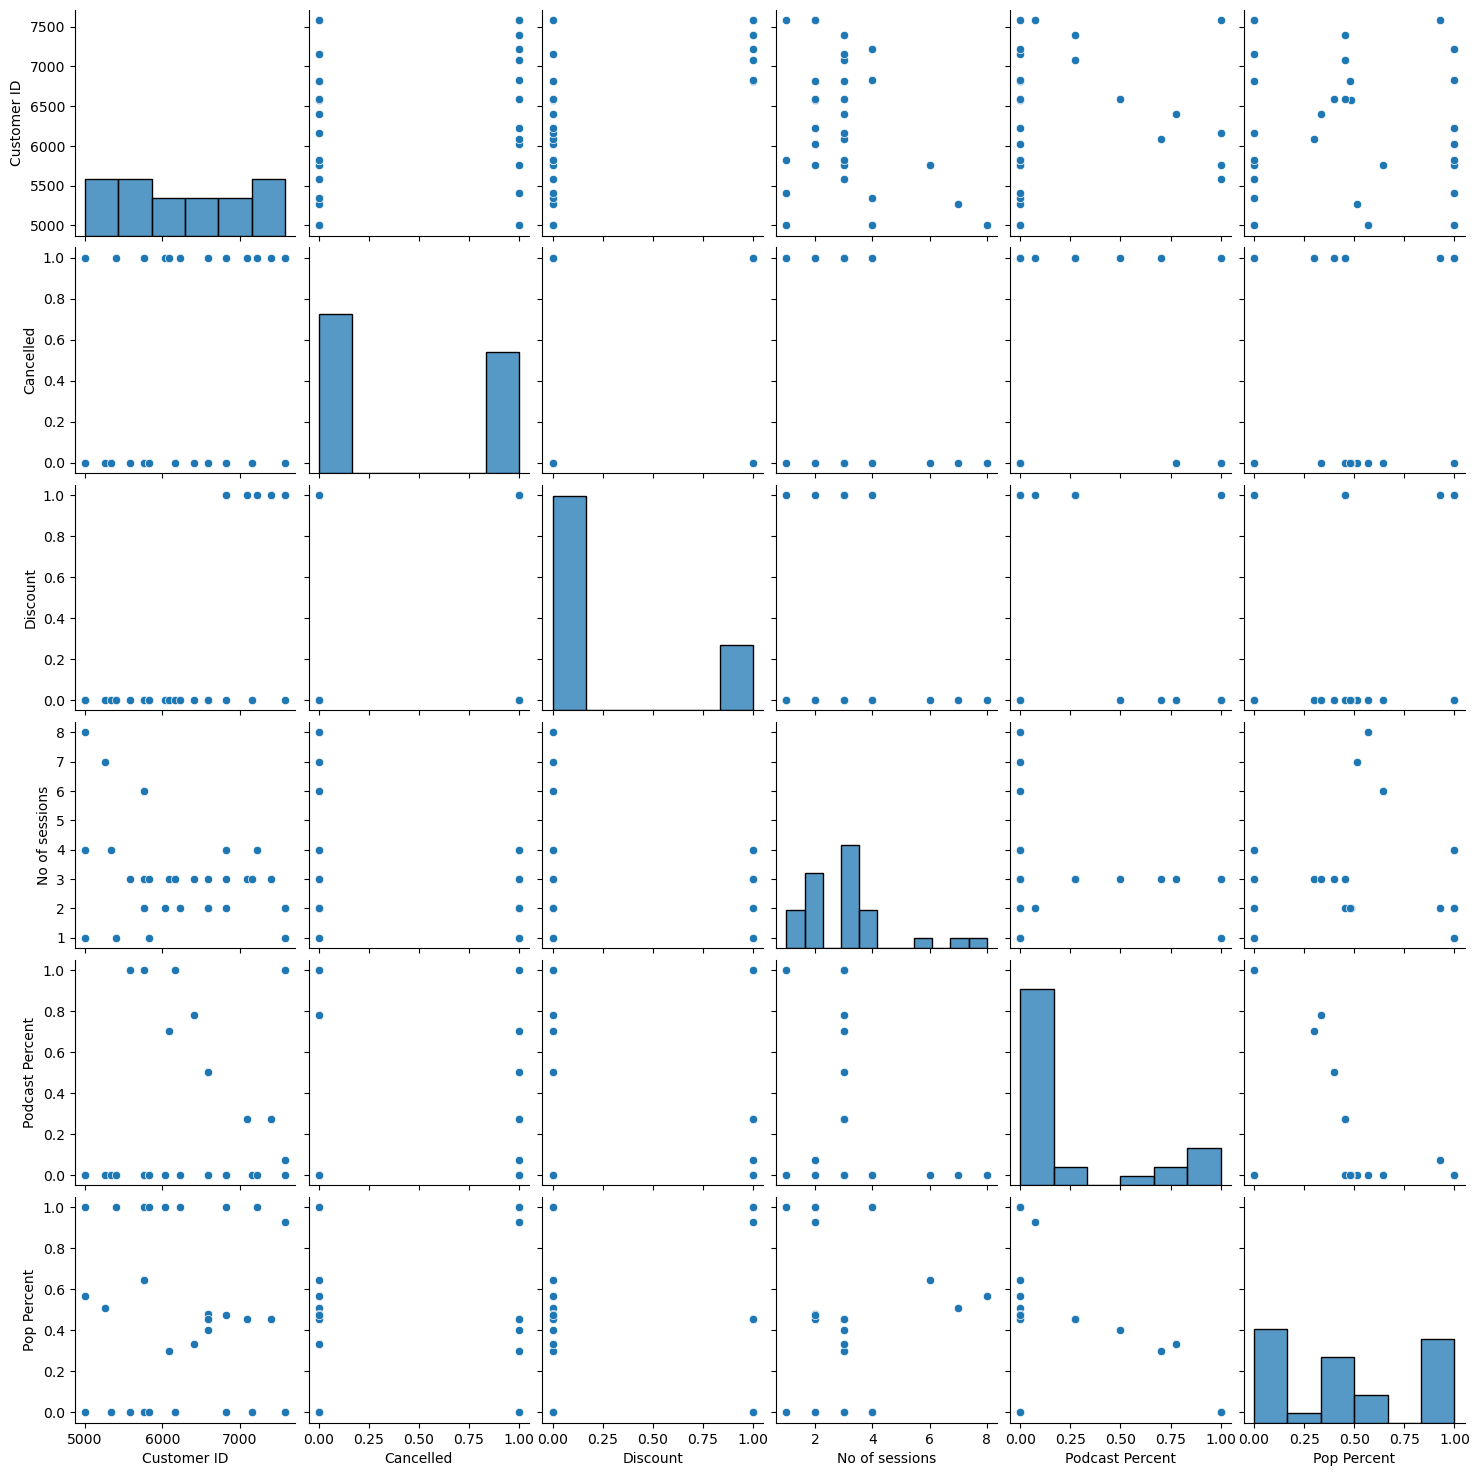

In [150]:
sns.pairplot(model_df)

In [151]:
model_df.corr()

,Customer ID,Cancelled,Discount,No of sessions,Podcast Percent,Pop Percent
Customer ID,1.000000,0.269942,0.648514,-0.337083,0.082884,-0.076129
Cancelled,0.269942,1.000000,0.471825,-0.333739,-0.007471,0.585630
Discount,0.648514,0.471825,1.000000,-0.048877,0.016760,0.112675
No of sessions,-0.337083,-0.333739,-0.048877,1.000000,-0.116558,-0.131156
Podcast Percent,0.082884,-0.007471,0.016760,-0.116558,1.000000,-0.477212
Pop Percent,-0.076129,0.585630,0.112675,-0.131156,-0.477212,1.000000


In [162]:
# OBSERVATIONS

# 1. As podcast% increases pop% decreases
# 2. Most customers have less than 3 listening sessions
# 3. Cancelled people have less no.of sessions

# GOOD PREDICTORS:

## Discount and Cancellations : 0.47 positive & not very strong corr - if they get discounts, they are likely to cancel.
## No. of sessions and Cancellations : A -ve 0.33 - More the listening, less likely they are to cancel.
## Pop Percent and Cancellations : A positive 0.58 corr - people who like Pop like to use this service.
## Podcast percent and Cancellations : No correlation. 

